# 02 — Collaborative Filtering from Scratch

This notebook walks through user-based and item-based collaborative filtering.
The goal is to understand the mechanics hands-on and observe where naive CF breaks down,
which motivates the move to matrix factorization in the next notebook.

**Sections**
1. Setup and data loading
2. Build the user-item matrix
3. User-based CF — similarity and recommendations
4. Item-based CF — similarity and recommendations
5. The sparsity problem firsthand
6. Evaluation

In [2]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from data_loader import load_all
from encoder import encode
from splitter import split
from matrix_builder import build_sparse_matrix
from cf_model import UserBasedCF, ItemBasedCF
from evaluator import evaluate_user_based_cf

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 1. Setup and Data Loading

In [3]:
ratings, movies, users = load_all()

encoded_ratings, user_encoder, movie_encoder, user_decoder, movie_decoder = encode(ratings)
train, test = split(encoded_ratings, test_ratio=0.2)

n_users = len(user_encoder)
n_movies = len(movie_encoder)

print(f'Train : {len(train):,} ratings')
print(f'Test  : {len(test):,} ratings')
print(f'Users : {n_users:,}')
print(f'Movies: {n_movies:,}')

Raw data already present, skipping download.
Encoders saved to data/processed/
Users  : 6040
Movies : 3706
Train : 800,167 ratings  (2000-04-25 => 2000-12-02)
Test  : 200,042 ratings  (2000-12-02 => 2003-02-28)
Splits saved to data/processed/
Train : 800,167 ratings
Test  : 200,042 ratings
Users : 6,040
Movies: 3,706


## 2. Build the User-Item Matrix

In [4]:
matrix = build_sparse_matrix(train, n_users, n_movies)

print(f'Matrix shape : {matrix.shape}')
print(f'Stored values: {matrix.nnz:,}')
print(f'Sparsity     : {1 - matrix.nnz / (n_users * n_movies):.4%}')

Matrix shape : 6,040 users x 3,706 movies
Stored ratings : 800,167
Sparsity : 96.4253%
Ratings per user  - mean: 132.5  min: 0  max: 1849
Ratings per movie - mean: 215.9  min: 0  max: 2902
Matrix shape : (6040, 3706)
Stored values: 800,167
Sparsity     : 96.4253%


## 3. User-Based CF

We find users similar to the target user and recommend movies they liked.
Similarity is computed using cosine similarity on the rating vectors.

In [5]:
user_cf = UserBasedCF(k=20)
user_cf.fit(matrix)
print('UserBasedCF fitted.')

UserBasedCF fitted.


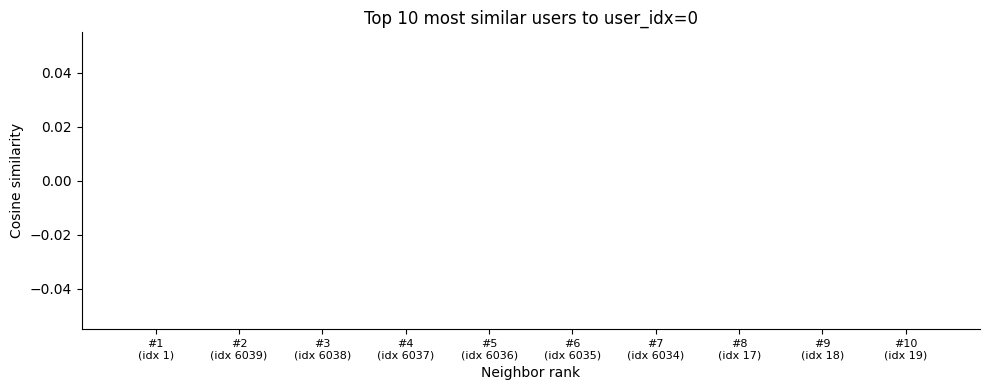

In [6]:
# inspect the similarity scores for a sample user
sample_user_idx = 0
sim_scores = user_cf._similarity[sample_user_idx].copy()
sim_scores[sample_user_idx] = -1  # exclude self

top_k_indices = np.argsort(sim_scores)[::-1][:10]
top_k_sims = sim_scores[top_k_indices]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(10), top_k_sims, color='steelblue')
ax.set_xlabel('Neighbor rank')
ax.set_ylabel('Cosine similarity')
ax.set_title(f'Top 10 most similar users to user_idx={sample_user_idx}')
ax.set_xticks(range(10))
ax.set_xticklabels([f'#{i+1}\n(idx {top_k_indices[i]})' for i in range(10)], fontsize=8)
plt.tight_layout()
plt.show()

In [7]:
# get recommendations for the sample user
recs = user_cf.recommend(sample_user_idx, n=10)

# decode movie indices back to raw movieIds and look up titles
rec_df = pd.DataFrame(recs, columns=['movie_idx', 'predicted_score'])
rec_df['movieId'] = rec_df['movie_idx'].map(movie_decoder)
rec_df = rec_df.merge(movies[['movieId', 'title_clean', 'genres']], on='movieId')
rec_df['genres'] = rec_df['genres'].apply(lambda g: ', '.join(g))
rec_df[['title_clean', 'genres', 'predicted_score']].round(3)

,title_clean,genres,predicted_score


In [8]:
# what has the sample user already rated highly?
user_rated = train[train['user_idx'] == sample_user_idx].sort_values('rating', ascending=False).head(10)
user_rated = user_rated.copy()
user_rated['movieId'] = user_rated['movie_idx'].map(movie_decoder)
user_rated = user_rated.merge(movies[['movieId', 'title_clean', 'genres']], on='movieId')
user_rated['genres'] = user_rated['genres'].apply(lambda g: ', '.join(g))
print('Movies already rated highly by this user:')
user_rated[['title_clean', 'genres', 'rating']].head(10)

Movies already rated highly by this user:


,title_clean,genres,rating


## 4. Item-Based CF

Instead of finding similar users, we find movies similar to ones the user already liked.
Adjusted cosine similarity is used to account for user rating bias.

In [9]:
item_cf = ItemBasedCF(k=20)
item_cf.fit(matrix)
print('ItemBasedCF fitted.')

ItemBasedCF fitted.


In [10]:
# find movies similar to a well-known movie
# Toy Story (1995) has movieId=1
toy_story_idx = movie_encoder.get(1)

if toy_story_idx is not None:
    sim_scores = item_cf._similarity[toy_story_idx].copy()
    sim_scores[toy_story_idx] = -1

    top_k = np.argsort(sim_scores)[::-1][:10]
    similar_df = pd.DataFrame({
        'movie_idx': top_k,
        'similarity': sim_scores[top_k]
    })
    similar_df['movieId'] = similar_df['movie_idx'].map(movie_decoder)
    similar_df = similar_df.merge(movies[['movieId', 'title_clean', 'genres']], on='movieId')
    similar_df['genres'] = similar_df['genres'].apply(lambda g: ', '.join(g))
    print('Movies most similar to Toy Story (1995):')
    similar_df[['title_clean', 'genres', 'similarity']].round(3)
else:
    print('Toy Story not found in encoder - try a different movieId.')

Movies most similar to Toy Story (1995):


In [11]:
# recommendations for the same sample user using item-based CF
item_recs = item_cf.recommend(sample_user_idx, n=10)

item_rec_df = pd.DataFrame(item_recs, columns=['movie_idx', 'predicted_score'])
item_rec_df['movieId'] = item_rec_df['movie_idx'].map(movie_decoder)
item_rec_df = item_rec_df.merge(movies[['movieId', 'title_clean', 'genres']], on='movieId')
item_rec_df['genres'] = item_rec_df['genres'].apply(lambda g: ', '.join(g))
print('Item-based CF recommendations:')
item_rec_df[['title_clean', 'genres', 'predicted_score']].round(3)

Item-based CF recommendations:


,title_clean,genres,predicted_score


## 5. The Sparsity Problem Firsthand

How many co-rated items do two users actually share?
Similarity scores computed from very few co-rated items are unreliable.

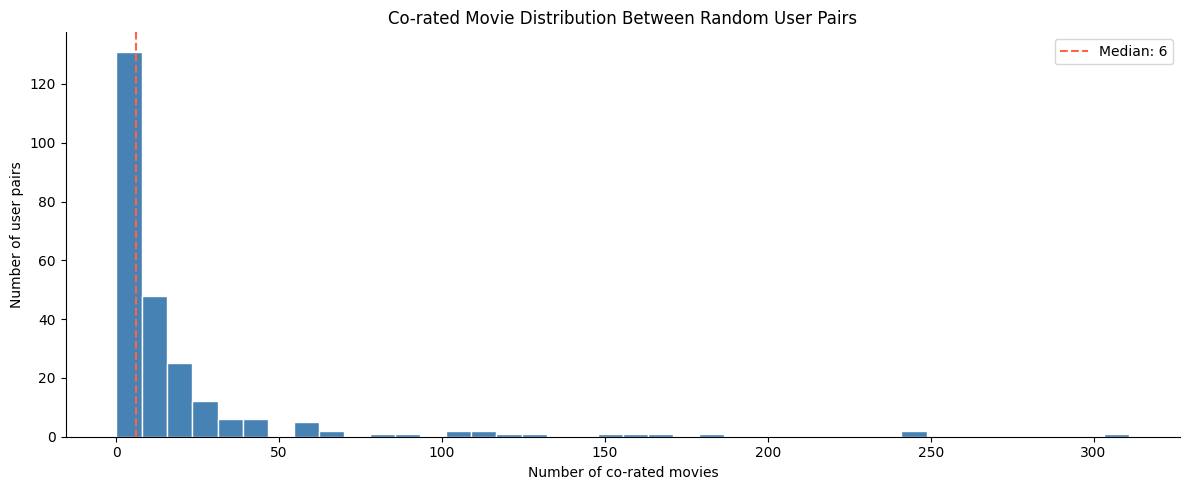

Mean co-rated   : 19.3
Median co-rated : 6
Pairs with 0 co-rated movies: 52 / 250


In [12]:
# sample 500 random user pairs and count their co-rated movies
rng = np.random.default_rng(42)
sample_users = rng.choice(n_users, size=500, replace=False)

co_rated_counts = []
for i in range(0, len(sample_users) - 1, 2):
    u1, u2 = sample_users[i], sample_users[i + 1]
    rated_u1 = set(matrix[u1].nonzero()[1])
    rated_u2 = set(matrix[u2].nonzero()[1])
    co_rated_counts.append(len(rated_u1 & rated_u2))

co_rated_counts = np.array(co_rated_counts)

fig, ax = plt.subplots()
ax.hist(co_rated_counts, bins=40, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of co-rated movies')
ax.set_ylabel('Number of user pairs')
ax.set_title('Co-rated Movie Distribution Between Random User Pairs')
ax.axvline(np.median(co_rated_counts), color='tomato', linestyle='--', label=f'Median: {np.median(co_rated_counts):.0f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mean co-rated   : {co_rated_counts.mean():.1f}')
print(f'Median co-rated : {np.median(co_rated_counts):.0f}')
print(f'Pairs with 0 co-rated movies: {(co_rated_counts == 0).sum()} / {len(co_rated_counts)}')

The low co-rated counts explain why CF similarity scores are unreliable for many user pairs.
A similarity score computed from 2-3 shared movies carries very little signal.
This is the core limitation that matrix factorization addresses.

## 6. Evaluation

In [13]:
print('Evaluating UserBasedCF (sample of 2000 test ratings)...')
rmse_user_cf = evaluate_user_based_cf(user_cf, test, sample_size=2000)
print(f'UserBasedCF  RMSE: {rmse_user_cf:.4f}')

print('\nEvaluating ItemBasedCF (sample of 2000 test ratings)...')
rmse_item_cf = evaluate_user_based_cf(item_cf, test, sample_size=2000)
print(f'ItemBasedCF  RMSE: {rmse_item_cf:.4f}')

Evaluating UserBasedCF (sample of 2000 test ratings)...
UserBasedCF  RMSE: 3.0173

Evaluating ItemBasedCF (sample of 2000 test ratings)...
ItemBasedCF  RMSE: 3.5337


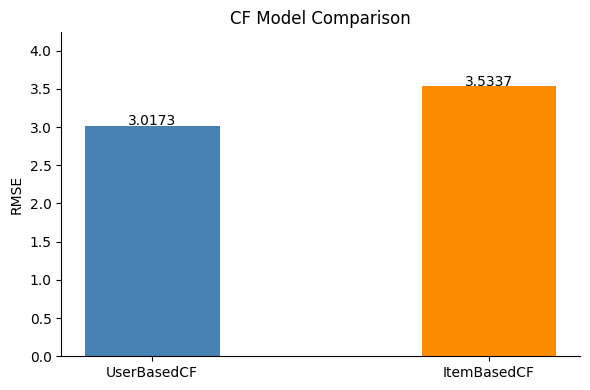

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
models = ['UserBasedCF', 'ItemBasedCF']
rmses = [rmse_user_cf, rmse_item_cf]
colors = ['steelblue', 'darkorange']

bars = ax.bar(models, rmses, color=colors, width=0.4)
for bar, rmse in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{rmse:.4f}', ha='center', fontsize=10)

ax.set_ylabel('RMSE')
ax.set_title('CF Model Comparison')
ax.set_ylim(0, max(rmses) * 1.2)
plt.tight_layout()
plt.show()

## Summary

- User-based and item-based CF produce reasonable recommendations for active users
- The co-rated movie analysis shows that most user pairs share very few movies,
  making similarity scores unreliable for a large fraction of the user base
- RMSE on the test set reflects this — CF struggles with sparse data
- The next notebook addresses this with matrix factorization,
  which learns dense latent representations and can compare users even without shared ratings